In [19]:
if(!require(readr)) install.packages("readr")
library (readr)

github= paste0("https://raw.githubusercontent.com/agronomy4future/",
               "raw_data_practice/refs/heads/main/cumulative_germination.csv")
df=data.frame(read_csv(url(github), show_col_types= FALSE))
print(head(df, 5))

  Treatment Days Rep Cumulative_germination
1   Control  116   1                   0.00
2   Control  120   1                   0.03
3   Control  123   1                   0.07
4   Control  126   1                   0.15
5   Control  128   1                   0.19


# R package - weibullfit

In [20]:
if(!require(remotes)) install.packages("remotes")
if (!requireNamespace("weibullfit", quietly = TRUE)) {
    remotes::install_github("agronomy4future/weibullfit", force= TRUE)
}
library(remotes)
library(weibullfit)

In [21]:
model= weibullfit(Cumulative_germination ~ Days, data= df, rep= "Rep")
print(model)

Weibull fit (SSweibull)
-----------------------
Model : Cumulative_germination ~ Days
N     : 61 points used for the curve  (replicate means)

Parameters:
    Asym     Drop      lrc      pwr 
  0.9454   0.9399 -84.8043  16.9708 

Event timing (from replicates):
  t_first      : 120 ± 0.7
  t_onset      : 125 ± 0.9
  n_rep        : 10

Event timing (from fitted curve):
  t_inflection : 147.4
  t_end        : 157.9

Curve-based quantiles:
   t5   t10   t25   t50   t75   t90   t95 
124.2 129.6 137.5 144.8 150.9 155.4 157.9 

Goodness of fit:
  RMSE  = 0.02
  NRMSE = 2.0%
  R2    = 0.9970
  AIC   = -301.0
  (fitted range: 0.0 to 1.0)


In [22]:
if(!require(dplyr)) install.packages("dplyr")
library(dplyr)

summary= df %>%
       group_by(Days) %>%
       dplyr::summarize(
       across(
        .cols= c(Cumulative_germination),
        .fns= list(
         Mean= ~mean(., na.rm= TRUE),
         n= ~length(.),
         se= ~sd(., na.rm= TRUE) / sqrt(length(.)))),
        .groups= "drop") %>%
        as.data.frame()

print(head(summary, 5))

  Days Cumulative_germination_Mean Cumulative_germination_n
1  109                 0.000000000                        3
2  112                 0.000000000                        4
3  114                 0.000000000                        6
4  116                 0.003333333                        9
5  120                 0.019000000                       10
  Cumulative_germination_se
1               0.000000000
2               0.000000000
3               0.000000000
4               0.002357023
5               0.004818944


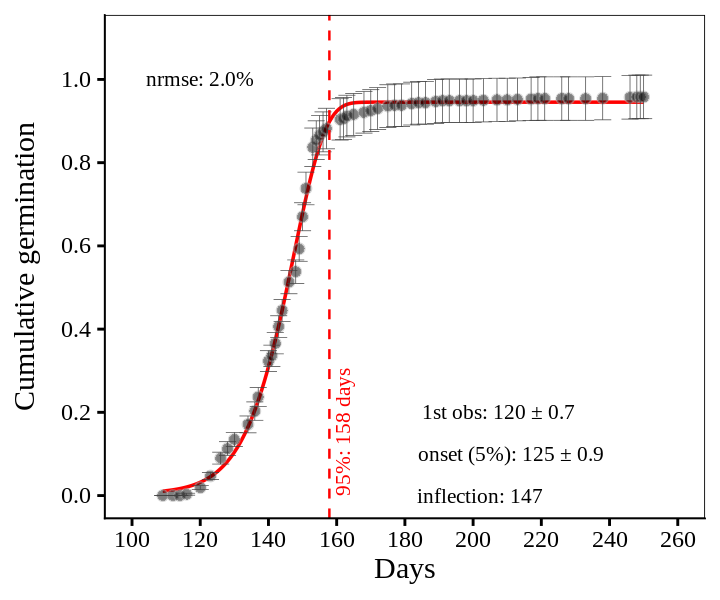

In [23]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig1= ggplot(data= summary,
       aes(x= Days, y= Cumulative_germination_Mean)) +
  geom_weibull(model, color="red", linewidth=1) +
  geom_point(size= 2.5, fill="black", color="grey65", alpha=0.5, shape=21, na.rm = TRUE) +

  geom_errorbar(aes(ymin=Cumulative_germination_Mean - Cumulative_germination_se,
                    ymax=Cumulative_germination_Mean + Cumulative_germination_se),
                    linewidth=0.2, width=5, color="grey25") +

# t_first
  annotate("text", x = 207.5, y = 0.2, size = 4.5,
           label = sprintf("1st obs: %.0f ± %.1f", model$t_first, model$t_first_se)) +

  # onset
  annotate("text", x = 211, y = 0.1, color = "black", size = 4.5,
           label = sprintf("onset (5%%): %.0f ± %.1f", model$t_onset, model$t_onset_se)) +

  # inflection
  annotate("text", x = 202, y = 0, size = 4.5, color = "black",
           label = sprintf("inflection: %.0f", model$t_inflection)) +

  # end
  geom_vline(xintercept = model$t_end, linetype = "dashed",
             linewidth = 0.7, color = "red") +
  annotate("text", x = model$t_end, y = 0, angle = 90, hjust = 0, vjust = 1.5,
           color = "red", size = 4.5,
           label = sprintf("95%%: %.0f days", model$t_end)) +

# nrmse
  annotate("text", x= 120, y= 1, size = 4.5,
           label= sprintf("nrmse: %.1f%%", model$nrmse * 100)) +

  scale_x_continuous(breaks= seq(100,260,20), limits = c(100,260)) +
  scale_y_continuous(breaks= seq(0, 1, 0.2), limits = c(0, 1.1)) +


  labs(x= "Days", y= "Cumulative germination") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position= "none",
        legend.title= element_blank(),
        legend.key.size= unit(0.6, 'cm'),
        legend.key= element_rect(color= alpha("white", .05),
                                  fill= alpha("white", .05)),
        legend.text= element_text(size= 10),
        legend.background= element_rect(fill= alpha("white", .05)),
        panel.border= element_rect(color= "black", fill= NA, linewidth= 0.5),
        strip.background= element_rect(color= "white", linewidth= 0.5, linetype = "solid"),
        axis.line= element_line(linewidth = 0.5, colour = "black"))

options(repr.plot.width=6, repr.plot.height=5)
print(Fig1)

ggsave("Fig1.png", plot= Fig1, width=6, height= 5, dpi= 300)

# Quadratic plateau model

In [24]:
fit.lm= lm(Cumulative_germination_Mean ~ poly(Days,2, raw=TRUE),data=summary)
a_parameter= fit.lm$coefficients[1]
b_parameter= fit.lm$coefficients[2]
c_parameter= fit.lm$coefficients[3]
x_mean= mean(df$Days)

In [25]:
qp= function(x, a, b, jp) {
  c= -0.5 * b / jp
  ifelse(x < jp,
          a + (b * x) + (c * x * x),
          a + (b * jp) + (c * jp * jp))
}

In [26]:
model= nls(formula=Cumulative_germination_Mean ~ qp(Days, a, b, jp),
           data=summary,
           start=list(a=a_parameter, b=b_parameter, jp=x_mean))
summary(model)


Formula: Cumulative_germination_Mean ~ qp(Days, a, b, jp)

Parameters:
     Estimate Std. Error t value Pr(>|t|)    
a   -5.324607   0.498148  -10.69 2.48e-15 ***
b    0.064631   0.006373   10.14 1.84e-14 ***
jp 194.762596   4.424958   44.02  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09779 on 58 degrees of freedom

Number of iterations to convergence: 9 
Achieved convergence tolerance: 7.997e-06


In [27]:
# Predict and evalulate
pred_lp = data.frame(Days = seq(100,260, 0.1))
pred_lp$Cumulative_germination_Mean = predict(model, newdata= pred_lp)
print(head(pred_lp, 5))

jp_val = round(coef(model)["jp"], 1)
print(jp_val)

   Days Cumulative_germination_Mean
1 100.0                  -0.5207392
2 100.1                  -0.5175963
3 100.2                  -0.5144566
4 100.3                  -0.5113202
5 100.4                  -0.5081872
   jp 
194.8 


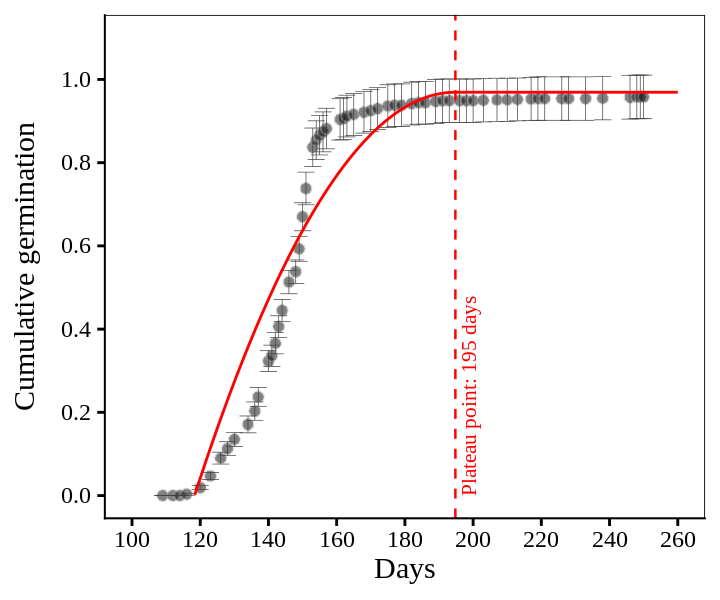

In [28]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

Fig2= ggplot(data= summary,
       aes(x= Days, y= Cumulative_germination_Mean)) +
  geom_point(size= 2.5, fill="black", color="grey65", alpha=0.5, shape=21, na.rm = TRUE) +
  geom_errorbar(aes(ymin=Cumulative_germination_Mean - Cumulative_germination_se,
                    ymax=Cumulative_germination_Mean + Cumulative_germination_se),
                    linewidth=0.2, width=5, color="grey25") +
  geom_line(data= pred_lp, color= "red", linewidth = 0.8, na.rm = TRUE) +
  geom_vline(xintercept = jp_val, linetype = "dashed",
             linewidth = 0.7, color = "red") +
  annotate("text", x = jp_val, y = 0, angle = 90, hjust = 0, vjust = 1.5,
           color = "red", size = 4.5,
           label = "Plateau point: 195 days") +
  scale_x_continuous(breaks= seq(100,260,20), limits = c(100,260)) +
  scale_y_continuous(breaks= seq(0, 1, 0.2), limits = c(0, 1.1)) +
  labs(x= "Days", y= "Cumulative germination") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position= "none",
        legend.title= element_blank(),
        legend.key.size= unit(0.6, 'cm'),
        legend.key= element_rect(color= alpha("white", .05),
                                  fill= alpha("white", .05)),
        legend.text= element_text(size= 10),
        legend.background= element_rect(fill= alpha("white", .05)),
        panel.border= element_rect(color= "black", fill= NA, linewidth= 0.5),
        strip.background= element_rect(color= "white", linewidth= 0.5, linetype = "solid"),
        axis.line= element_line(linewidth = 0.5, colour = "black"))

options(repr.plot.width=6, repr.plot.height=5)
print(Fig2)

ggsave("Fig2.png", plot= Fig2, width=6, height= 5, dpi= 300)